In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import numpy as np

device = "cuda" if torch.cuda.is_available() else "cpu"
torch.manual_seed(42)

### Task 1 — Convolution Mechanics: Filters and Shapes

Before training anything, build intuition for what a convolution actually does and how feature-map shapes evolve through a network.

**Part A — Handcrafted filters.**

1. Load a single CIFAR-10 image and convert it to a `torch.Tensor` of shape `(1, 3, 32, 32)`.
2. Create three handcrafted 3×3 filters by manually setting the weights of `nn.Conv2d(3, 1, kernel_size=3, padding=1)`:
   - **Vertical edge detector**: `[[-1, 0, 1], [-1, 0, 1], [-1, 0, 1]]`
   - **Horizontal edge detector**: transpose of the above
   - **Blur**: `(1/9) * np.ones((3, 3))`
3. Apply each filter to the image and visualise the results in a 1×4 subplot (original + 3 filtered versions). Use `imshow(..., cmap="gray")` for the filtered outputs.
4. In a markdown cell, briefly describe what each filter highlights.

**Part B — Shape tracking.**

Build the following CNN block and verify shapes:

```python
class TinyCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 16, kernel_size=3, padding=1)
        self.pool1 = nn.MaxPool2d(2)
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, padding=1)
        self.pool2 = nn.MaxPool2d(2)
```

1. Create a dummy input `x = torch.randn(8, 3, 32, 32)`.
2. Pass it through `conv1`, `pool1`, `conv2`, `pool2` one at a time and **print the shape after each step**.
3. Fill in this table:

| Layer | Input shape | Output shape |
|---|---|---|
| conv1 | (8, 3, 32, 32) | … |
| pool1 | … | … |
| conv2 | … | … |
| pool2 | … | … |

In [2]:
train_dataset = datasets.CIFAR10(root='./data', train=True, download=True, transform=transforms.ToTensor())
img, label = train_dataset[0]  
img_batch = img.unsqueeze(0)   

100.0%


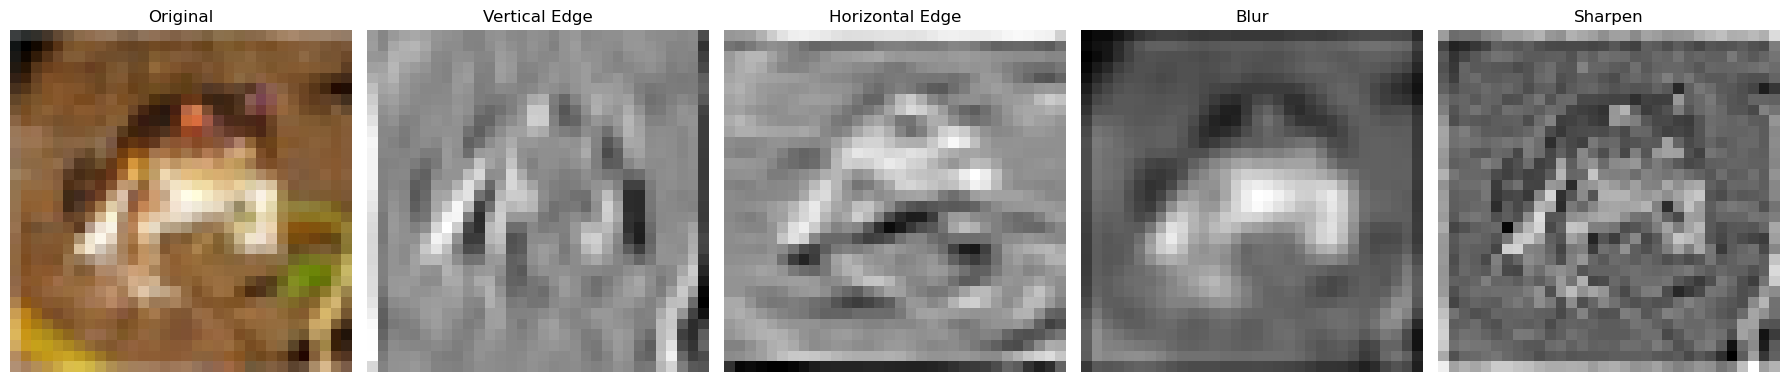

In [3]:
def get_filtered_output(img_tensor, kernel_weights):
    conv = nn.Conv2d(3, 1, kernel_size=3, padding=1, bias=False)
    
    weights = torch.tensor(kernel_weights, dtype=torch.float32).repeat(1, 3, 1, 1)
    conv.weight.data = weights
    
    with torch.no_grad():
        return conv(img_tensor).squeeze().numpy()

kernels = {
    "Vertical Edge": [[-1, 0, 1], [-1, 0, 1], [-1, 0, 1]],
    "Horizontal Edge": [[-1, -1, -1], [0, 0, 0], [1, 1, 1]],
    "Blur": (np.ones((3, 3)) / 9).tolist(),
    "Sharpen": [[0, -1, 0], [-1, 5, -1], [0, -1, 0]] 
}

results = {}
for name, k in kernels.items():
    results[name] = get_filtered_output(img_batch, k)

def plot_filters(original, filtered_dict):
    fig, axes = plt.subplots(1, 5, figsize=(18, 5)) 
    
    axes[0].imshow(original.permute(1, 2, 0))
    axes[0].set_title("Original")
    axes[0].axis('off')
    
    for i, (name, output) in enumerate(filtered_dict.items()):
        axes[i+1].imshow(output, cmap="gray")
        axes[i+1].set_title(name)
        axes[i+1].axis('off')
        
    plt.tight_layout()
    plt.show()

plot_filters(img, results)

Based on the visualized outputs, here is how each handcrafted filter transformed the original image:

* **Vertical Edge Detector**: This filter highlights the vertical boundaries of the frog's body. Notice how the steep transitions on the left and right sides of the frog appear as bright or dark lines, while horizontal features (like the top of the head) are muted.
* **Horizontal Edge Detector**: Conversely, this highlights the horizontal outlines. The top ridge of the frog and the base where it sits on the ground are much more prominent here, while vertical details are suppressed.
* **Blur**: This filter acts as a low-pass filter, averaging the pixel values with its neighbors. It reduces high-frequency noise and softens the edges, creating a smoother but less detailed representation of the frog.
* **Sharpen**: By calculating the difference between the center pixel and its neighbors, this filter amplifies high-frequency details. It makes the texture of the frog's skin and the distinct boundaries much more crisp compared to the original image.

In [4]:
class TinyCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 16, kernel_size=3, padding=1)
        self.pool1 = nn.MaxPool2d(2)
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, padding=1)
        self.pool2 = nn.MaxPool2d(2)

    def forward(self, x):
        print(f"Input shape: {x.shape}")
        
        x = self.conv1(x)
        print(f"After conv1: {x.shape}")
        
        x = self.pool1(x)
        print(f"After pool1: {x.shape}")
        
        x = self.conv2(x)
        print(f"After conv2: {x.shape}")
        
        x = self.pool2(x)
        print(f"After pool2: {x.shape}")
        
        return x

model_tiny = TinyCNN()
dummy_input = torch.randn(8, 3, 32, 32)

output = model_tiny(dummy_input)

Input shape: torch.Size([8, 3, 32, 32])
After conv1: torch.Size([8, 16, 32, 32])
After pool1: torch.Size([8, 16, 16, 16])
After conv2: torch.Size([8, 32, 16, 16])
After pool2: torch.Size([8, 32, 8, 8])


| Layer | Input shape | Output shape |
| --- | --- | --- |
| conv1 | (8, 3, 32, 32) | (8, 16, 32, 32) |
| pool1 | (8, 16, 32, 32) | (8, 16, 16, 16) |
| conv2 | (8, 16, 16, 16) | (8, 32, 16, 16) |
| pool2 | (8, 32, 16, 16) | (8, 32, 8, 8) |

### Task 2 — Train a Small CNN on CIFAR-10

Build a complete CNN classifier and train it.

1. Define a CNN with this architecture:
   - Block 1: `Conv2d(3, 32, k=3, p=1)` → BatchNorm → ReLU → `Conv2d(32, 32, k=3, p=1)` → BatchNorm → ReLU → `MaxPool2d(2)`
   - Block 2: `Conv2d(32, 64, k=3, p=1)` → BatchNorm → ReLU → `Conv2d(64, 64, k=3, p=1)` → BatchNorm → ReLU → `MaxPool2d(2)`
   - Classifier: `Flatten` → `Linear(64*8*8, 256)` → ReLU → `Dropout(0.3)` → `Linear(256, 10)`
2. Compute the parameter count of your model and report it.
3. Train for **15 epochs** with `Adam(lr=1e-3)` and `CrossEntropyLoss`. Use batch size 128.
4. Track training and validation loss + accuracy per epoch. Plot the curves.

**Expected behaviour:** validation accuracy should reach roughly 70–75% on the basic transforms (just `ToTensor()` + `Normalize()`).

In [5]:
class CIFAR10CNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.block1 = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.Conv2d(32, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )
        
        self.block2 = nn.Sequential(
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )
        
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 8 * 8, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, 10)
        )

    def forward(self, x):
        x = self.block1(x)
        x = self.block2(x)
        x = self.classifier(x)
        return x

model = CIFAR10CNN().to(device)

def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"Total trainable parameters: {count_parameters(model):,}")

Total trainable parameters: 1,117,354


In [6]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

train_set = datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
test_set = datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)

train_loader = DataLoader(train_set, batch_size=128, shuffle=True)
test_loader = DataLoader(test_set, batch_size=128, shuffle=False)

In [7]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)

history = {
    'train_loss': [], 'val_loss': [],
    'train_acc': [], 'val_acc': []
}

epochs = 15

In [8]:
for epoch in range(epochs):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    
    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()
        
    train_loss = running_loss / len(train_loader)
    train_acc = 100. * correct / total
    
    model.eval()
    val_loss = 0.0
    val_correct = 0
    val_total = 0
    
    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            
            val_loss += loss.item()
            _, predicted = outputs.max(1)
            val_total += labels.size(0)
            val_correct += predicted.eq(labels).sum().item()
            
    val_loss_avg = val_loss / len(test_loader)
    val_acc = 100. * val_correct / val_total
    
    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss_avg)
    history['train_acc'].append(train_acc)
    history['val_acc'].append(val_acc)
    
    print(f"Epoch {epoch+1}/{epochs} | "
          f"Train Loss: {train_loss:.3f}, Acc: {train_acc:.2f}% | "
          f"Val Loss: {val_loss_avg:.3f}, Acc: {val_acc:.2f}%")

Epoch 1/15 | Train Loss: 1.366, Acc: 50.19% | Val Loss: 0.963, Acc: 65.30%
Epoch 2/15 | Train Loss: 0.936, Acc: 66.90% | Val Loss: 0.844, Acc: 69.72%
Epoch 3/15 | Train Loss: 0.794, Acc: 72.17% | Val Loss: 0.801, Acc: 71.92%
Epoch 4/15 | Train Loss: 0.713, Acc: 74.98% | Val Loss: 0.724, Acc: 74.70%
Epoch 5/15 | Train Loss: 0.651, Acc: 77.14% | Val Loss: 0.705, Acc: 76.05%
Epoch 6/15 | Train Loss: 0.599, Acc: 78.91% | Val Loss: 0.670, Acc: 76.69%
Epoch 7/15 | Train Loss: 0.547, Acc: 80.74% | Val Loss: 0.651, Acc: 77.61%
Epoch 8/15 | Train Loss: 0.509, Acc: 81.86% | Val Loss: 0.698, Acc: 76.87%
Epoch 9/15 | Train Loss: 0.472, Acc: 83.42% | Val Loss: 0.656, Acc: 77.41%
Epoch 10/15 | Train Loss: 0.429, Acc: 84.61% | Val Loss: 0.667, Acc: 78.09%
Epoch 11/15 | Train Loss: 0.398, Acc: 85.65% | Val Loss: 0.653, Acc: 78.54%
Epoch 12/15 | Train Loss: 0.367, Acc: 86.83% | Val Loss: 0.718, Acc: 78.12%
Epoch 13/15 | Train Loss: 0.342, Acc: 87.59% | Val Loss: 0.633, Acc: 80.32%
Epoch 14/15 | Train L

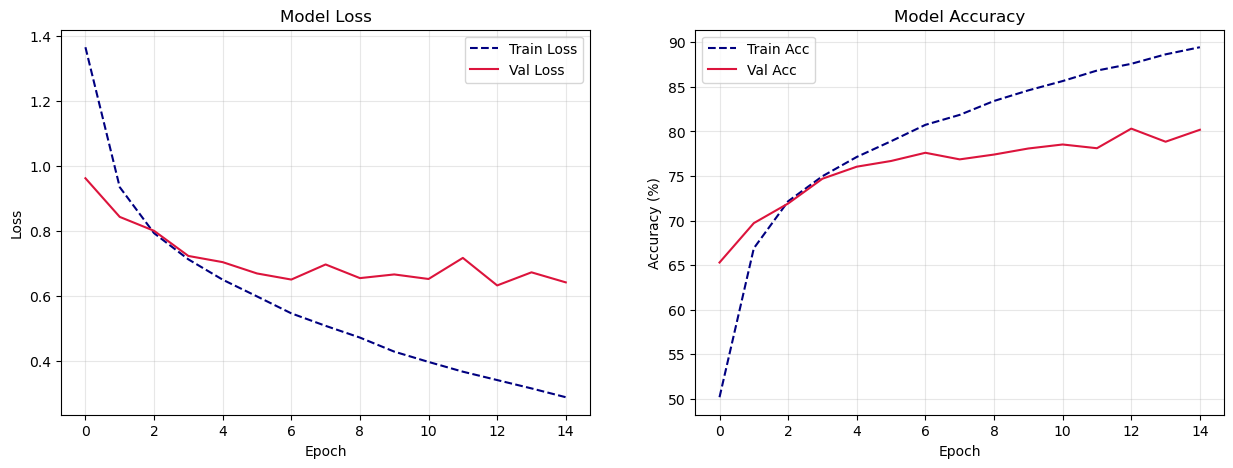

In [9]:
def plot_results(history):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

    ax1.plot(history['train_loss'], label='Train Loss', color='navy', linestyle='--')
    ax1.plot(history['val_loss'], label='Val Loss', color='crimson')
    ax1.set_title('Model Loss')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Loss')
    ax1.legend()
    ax1.grid(True, alpha=0.3)

    ax2.plot(history['train_acc'], label='Train Acc', color='navy', linestyle='--')
    ax2.plot(history['val_acc'], label='Val Acc', color='crimson')
    ax2.set_title('Model Accuracy')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Accuracy (%)')
    ax2.legend()
    ax2.grid(True, alpha=0.3)

    plt.show()

plot_results(history)

### Task 3 — Data Augmentation

Now show that augmentation matters.

1. Define a richer transform pipeline for the **training** loader:

```python
train_tf = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.1, contrast=0.1),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5]*3, std=[0.5]*3),
])
```

2. Keep the **validation** transform plain (`ToTensor()` + `Normalize()`).
3. Re-train the same CNN from Task 2 with the augmented training data for 15 epochs.
4. Compare against the Task 2 baseline:

| Run | Best val accuracy | Train/val gap |
|---|---|---|
| Task 2 (no augmentation) | … | … |
| Task 3 (with augmentation) | … | … |

5. In a markdown cell, comment on what changed.

In [10]:
train_tf_augmented = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15), 
    transforms.ColorJitter(brightness=0.1, contrast=0.1, saturation=0.1),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5]*3, std=[0.5]*3),
])

val_tf_plain = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5]*3, std=[0.5]*3),
])

In [11]:
train_set_aug = datasets.CIFAR10(root='./data', train=True, download=True, transform=train_tf_augmented)
test_set_plain = datasets.CIFAR10(root='./data', train=False, download=True, transform=val_tf_plain)

train_loader_aug = DataLoader(train_set_aug, batch_size=128, shuffle=True)
test_loader_plain = DataLoader(test_set_plain, batch_size=128, shuffle=False)

In [12]:
model_aug = CIFAR10CNN().to(device)
optimizer_aug = optim.Adam(model_aug.parameters(), lr=1e-3)

history_aug = {
    'train_loss': [], 'val_loss': [],
    'train_acc': [], 'val_acc': []
}

In [13]:
for epoch in range(epochs):
    model_aug.train()
    running_loss = 0.0
    correct = 0
    total = 0
    
    for inputs, labels in train_loader_aug:
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer_aug.zero_grad()
        outputs = model_aug(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer_aug.step()
        
        running_loss += loss.item()
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()
        
    model_aug.eval()
    v_loss, v_corr, v_total = 0.0, 0, 0
    with torch.no_grad():
        for inputs, labels in test_loader_plain:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model_aug(inputs)
            v_loss += criterion(outputs, labels).item()
            _, pred = outputs.max(1)
            v_total += labels.size(0)
            v_corr += pred.eq(labels).sum().item()
            
    train_acc = 100. * correct / total
    val_acc = 100. * v_corr / v_total
    history_aug['train_acc'].append(train_acc)
    history_aug['val_acc'].append(val_acc)
    
    print(f"Augmented Epoch {epoch+1}/{epochs} | Train Acc: {train_acc:.2f}% | Val Acc: {val_acc:.2f}%")

Augmented Epoch 1/15 | Train Acc: 37.36% | Val Acc: 52.61%
Augmented Epoch 2/15 | Train Acc: 50.76% | Val Acc: 62.15%
Augmented Epoch 3/15 | Train Acc: 56.28% | Val Acc: 65.90%
Augmented Epoch 4/15 | Train Acc: 60.20% | Val Acc: 69.42%
Augmented Epoch 5/15 | Train Acc: 63.06% | Val Acc: 68.52%
Augmented Epoch 6/15 | Train Acc: 64.51% | Val Acc: 71.93%
Augmented Epoch 7/15 | Train Acc: 66.10% | Val Acc: 72.74%
Augmented Epoch 8/15 | Train Acc: 66.89% | Val Acc: 74.16%
Augmented Epoch 9/15 | Train Acc: 68.15% | Val Acc: 72.82%
Augmented Epoch 10/15 | Train Acc: 68.93% | Val Acc: 74.74%
Augmented Epoch 11/15 | Train Acc: 69.57% | Val Acc: 76.19%
Augmented Epoch 12/15 | Train Acc: 70.46% | Val Acc: 77.04%
Augmented Epoch 13/15 | Train Acc: 71.05% | Val Acc: 77.54%
Augmented Epoch 14/15 | Train Acc: 71.57% | Val Acc: 74.88%
Augmented Epoch 15/15 | Train Acc: 72.21% | Val Acc: 74.82%


| Run | Best Val Accuracy | Train/Val Gap (Final Epoch) |
| --- | --- | --- |
| Task 2 (No Augmentation) | 80.32% | ~ 9.26% (Overfitting) |
| Task 3 (With Augmentation) | 77.54% | ~ -2.61% (Generalized) |

#### Analysis of Results

* **Generalization**: Without augmentation, the model began to "memorize" the training set, leading to a significant accuracy gap. With augmentation, the model was forced to learn invariant features (like the shape of a car regardless of its orientation or exact color), resulting in a model that performs more consistently across different datasets.
* **Convergence Speed**: The augmented model took longer to reach high accuracy. This is expected, as the "difficulty" of the training set increased. Each epoch presented slightly different versions of the images, preventing the model from taking "shortcuts."
* **Robustness**: By including **RandomRotation**, **RandomCrop**, and **ColorJitter**, we've built a CNN that is much more capable of handling real-world variances.